In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import lightgbm as lgb
import json
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx           # For building and manipulating causal/knowledge graphs
import calendar
import pickle


from eventregistry import *     # Event Registry API for fetching news articles
from IPython.display import display, Markdown
from IPython.display import display
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from ta.trend import MACD, SMAIndicator           # Technical analysis indicators
from ta.momentum import RSIIndicator, ROCIndicator
from ta.volatility import BollingerBands
from typing import Optional, List, Tuple, Dict, Any
from dotenv import load_dotenv
from datetime import datetime, timedelta
from openai import OpenAI        # OpenAI client for GPT-based causal extraction
from pyvis.network import Network # Interactive graph visualization (HTML output)
from IPython.display import SVG, display
import sys
from pathlib import Path



# Ignore all warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Set display options so we can see all columns and enough rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')



# Set display options (repeated for consistency after style changes)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.5,
})


# ─────────────────────────────────── Import custom methods that I have implemented  ──────────────────────────────────────────
try:
    from utils.internal_methods import visualize_important_features
    from utils.internal_methods import visualize_knowledge_graph
    from utils.internal_methods import build_unified_graph, visualize_unified_graph
except ModuleNotFoundError:
    # Make sure project root (or its parent) is on sys.path
    for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (base / "utils").exists():
            sys.path.insert(0, str(base))
            break
    from utils.internal_methods import visualize_important_features
    from utils.internal_methods import visualize_knowledge_graph
    from utils.internal_methods import build_unified_graph, visualize_unified_graph


# ── Global constants ────────────────────────────────────────────────────────
FORECAST_HORIZONS = [1, 7, 14, 30]  # Days ahead to forecast
TEST_SIZE_DAYS = 30                  # Last 30 days reserved for testing
RANDOM_STATE = 42                    # Reproducibility seed
LSTM_LOOKBACK = 14                   # LSTM sequence length (14 days)
MODEL_DIR = '../models'              # Directory where trained models are saved

# Seed all random number generators for reproducibility
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create model directory if it doesn't exist
# os.makedirs(MODEL_DIR, exist_ok=True)

# ── Load API keys from .env file ────────────────────────────────────────────
# These keys are needed for:
#   - OpenAI: LLM-based causal triplet extraction (GPT-5-mini / GPT-5)
#   - Groq: Alternative LLM provider (not used in current pipeline)
#   - Event Registry: Fetching news articles about supply chain events
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
event_registry = os.getenv("EVENT_REGISTRY")
my_openai_api_key = os.getenv("MY_OPENAI_API_KEY")


print("✓ Imports complete")

✓ Imports complete


<br> <br>


## Load sub Causal Graph & Event Graph

In [2]:
date = "20260328"
time = "152610"
row_number = 936

sub_causal_graph_importance_df = pd.read_csv(f"../importance_df/importance_df_{row_number}.csv")
causal_graph_svg = f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.svg"
feature_impoprtance = f"../xai/feature_importance_top20_{row_number}.svg"
enriched_kg = pd.read_csv(f"../enriched_knowledge_graph/enriched_kg_{date}_{time}_{row_number}.csv")
sub_causal_graph = pd.read_csv(f"../causal_graph/sub_causal_graph/sub_causal_graph_{row_number}.csv")

### Visualize sub causal graph

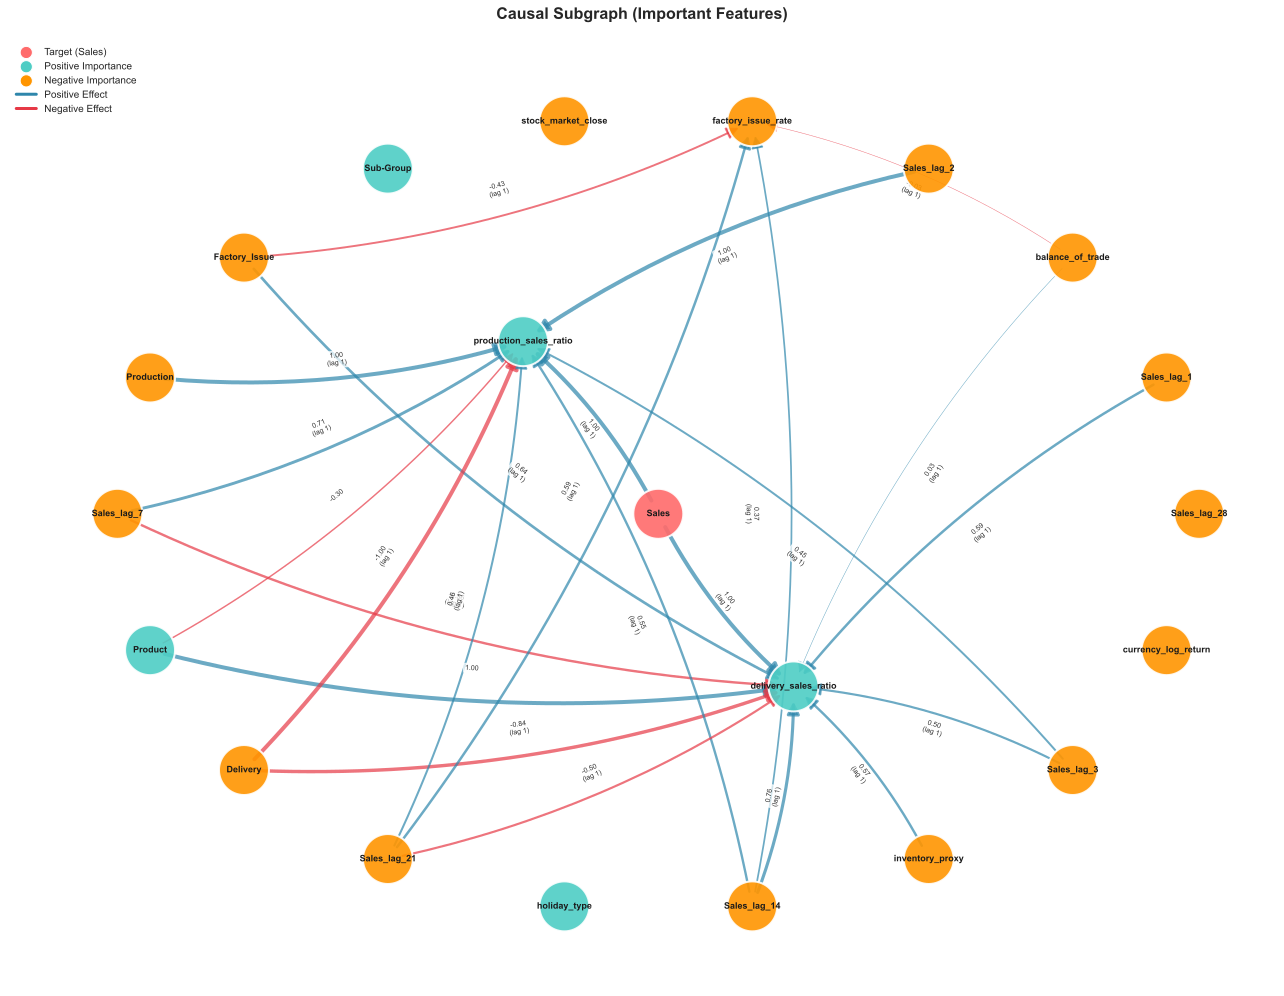

In [3]:
if os.path.exists(causal_graph_svg):
    display(SVG(filename=causal_graph_svg))
else:
    print(f"File not found: {causal_graph_svg}")

### Visualize the feature importance

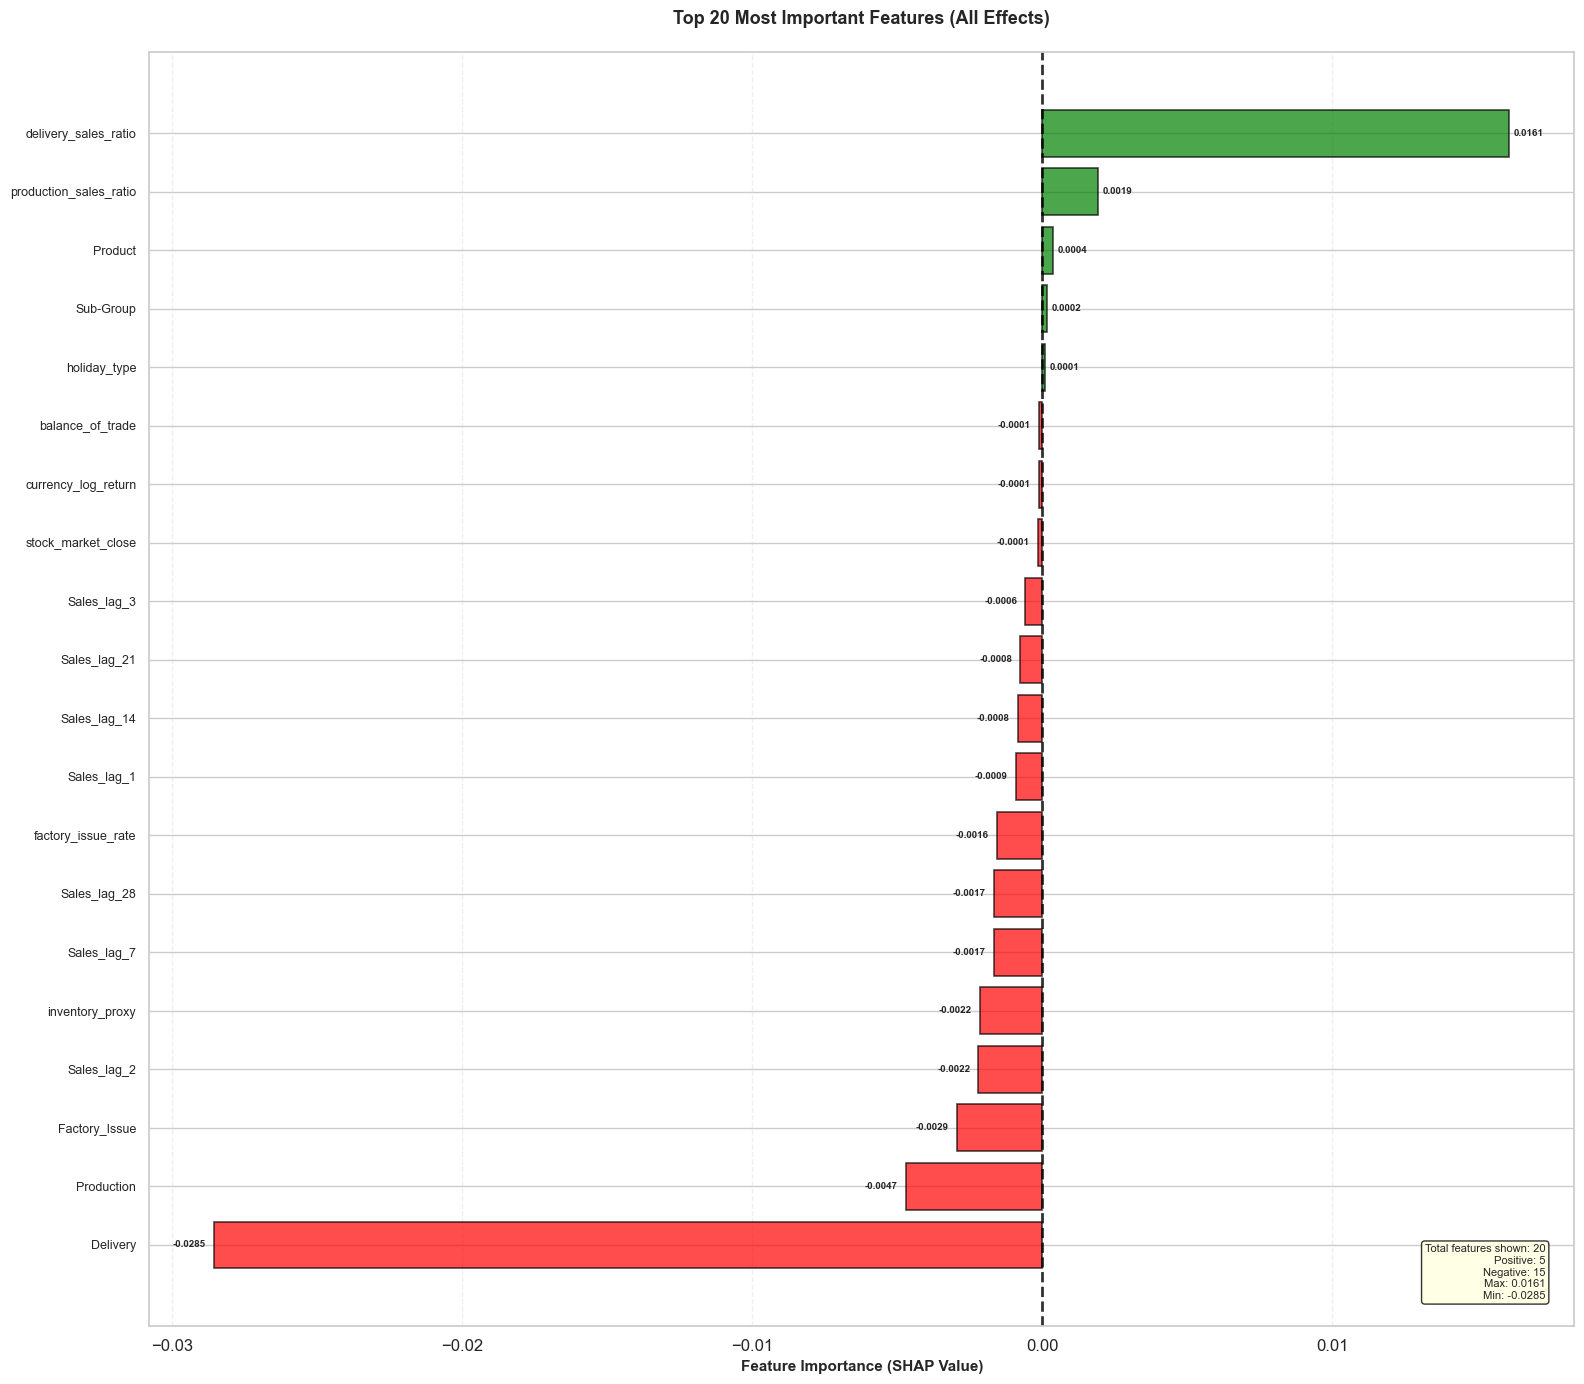


FEATURE IMPORTANCE VISUALIZATION SUMMARY
Effect type filter: both
Features in original dataset: 20
Features excluded (near-zero): 0
Features with non-zero effects: 20
Features displayed (top 20): 20
  - Positive effects: 5
  - Negative effects: 15


In [4]:
if os.path.exists(feature_impoprtance):
    display(SVG(filename=feature_impoprtance))
else:
    visualize_important_features(sub_causal_graph_importance_df, top_n=20, effect_type='both', figsize=(16, 14), fontsize=9)

## Visualize the knowledge graph

In [5]:
# ── Example usage ────────────────────────────────────────────────────────────
# Available themes :  "light"  |  "dark"  |  "pastel"  |  "highcontrast"
# Edge label styles:  "text"   |  "rectangle"  |  "roundrect"  |  "ellipse"  |  "circle"  |  "diamond"

visualize_knowledge_graph(
    df=enriched_kg,
    output_file=f"../kg_visualization/refined_triplet_kg_{date}_{time}_{row_number}.html",
    theme="highcontrast",                 # white background, readable colours
    node_size=25,                  # uniform node radius (px)
    node_font_size=14,             # node label font size (px)
    edge_font_size=12,             # edge label font size (px)
    edge_label_style= "roundrect"  #"text",    # plain text (no shape behind label)
)

Parsed 19 triplets from 19 rows
Interactive graph saved to: ../kg_visualization/refined_triplet_kg_20260328_152610_936.html
  Theme: highcontrast  |  Nodes: 22  |  Edges: 19
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Currency Movement, Global Shock, Industry Activity, Infrastructure, Market Dynamics, Monetary Policy


'../kg_visualization/refined_triplet_kg_20260328_152610_936.html'

<br> <br>

## Combine the Event Graph and Causal Graph

In [6]:
cols = ["url","title", "date", "feature", "refined_triplet", "attribute"]

enriched_kg[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,balance_of_trade,(New Single Point Mooring Facility) ── deterio...,"""New Single Point Mooring Facility: Infrastruc..."
1,https://www.laprensalatina.com/imf-approves-4-...,IMF approves $4.7 billion loan package for Ban...,2023-01-31,currency_log_return,(Russian invasion of Ukraine) ── depreciate ──...,"""Russian invasion of Ukraine: Global Shock"""
2,https://www.myanmarnews.net/news/273832902/ban...,Bangladesh government should think twice befor...,2023-05-16,currency_log_return,(Russia's invasion of Ukraine) ── depreciate ─...,"""Russia's invasion of Ukraine: Global Shock"""
3,https://www.myanmarnews.net/news/273832902/ban...,Bangladesh government should think twice befor...,2023-05-16,balance_of_trade,(Adoption of the Yuan) ── deteriorate ──> (bal...,"""Adoption of the Yuan: Currency Movement"""
4,https://www.enca.com/life/bangladesh-shuts-sch...,"Bangladesh shuts schools, cuts power in longes...",2023-06-07,currency_log_return,(25 Percent Taka Depreciation) ── depreciate ─...,"""25 Percent Taka Depreciation: Currency Movement"""
5,https://www.bssnews.net/national-budget-2023-2...,Govt aims to sustain economic recovery: Kamal ...,2023-06-01,currency_log_return,(Bangladesh Exchange Rate Depreciation) ── sta...,"""Bangladesh Exchange Rate Depreciation: Curren..."
6,https://www.bssnews.net/national-budget-2023-2...,Govt aims to sustain economic recovery: Kamal ...,2023-06-01,currency_log_return,(Bangladesh Foreign Exchange Rate Depreciation...,"""Post-war global inflation: Global Shock"", ""Fo..."
7,https://www.bssnews.net/national-budget-2023-2...,No possibility of inflation from govt. borrowi...,2023-06-02,stock_market_close,(Central Bank Policy Support) ── rise ──> (sto...,"""Central Bank Policy Support: Monetary Policy"""
8,https://asianews.network/is-renewable-deployme...,Is renewable deployment suffering from fossil ...,2023-04-20,currency_log_return,(Bangladesh Foreign Exchange Crisis) ── deprec...,"""Bangladesh Foreign Exchange Crisis: Monetary ..."
9,https://www.bssnews.net/business/126830,US hails Bangladesh for lifting fumigation req...,2023-05-22,balance_of_trade,(High Quality U.S. Cotton Imports) ── improve ...,"""High Quality U.S. Cotton Imports: Market Dyna..."


In [7]:
def filter_sub_causal_graph_by_features(clean_sub_causal_graph, enriched_kg_df):
    feature_set = set(enriched_kg_df["feature"].dropna())
    mask = (clean_sub_causal_graph["source"].isin(feature_set) | clean_sub_causal_graph["target"].isin(feature_set))
    return clean_sub_causal_graph.loc[mask].reset_index(drop=True)


# Example usage in your notebook:
filtered_sub_causal_graph_df = filter_sub_causal_graph_by_features(
    sub_causal_graph.drop(columns=["Unnamed: 0"]),
    enriched_kg
)

filtered_sub_causal_graph_df

,source,target,weight
0,balance_of_trade,delivery_sales_ratio,0.033258
1,balance_of_trade,factory_issue_rate,-0.032606


In [8]:
balance_of_trade_rows = enriched_kg.loc[enriched_kg["feature"] == "balance_of_trade"].reset_index(drop=True)
balance_of_trade_rows[cols]

,url,title,date,feature,refined_triplet,attribute
0,https://www.hellenicshippingnews.com/commodity...,Commodity Tracker: 5 charts to watch this week,2023-06-20,balance_of_trade,(New Single Point Mooring Facility) ── deterio...,"""New Single Point Mooring Facility: Infrastruc..."
1,https://www.myanmarnews.net/news/273832902/ban...,Bangladesh government should think twice befor...,2023-05-16,balance_of_trade,(Adoption of the Yuan) ── deteriorate ──> (bal...,"""Adoption of the Yuan: Currency Movement"""
2,https://www.bssnews.net/business/126830,US hails Bangladesh for lifting fumigation req...,2023-05-22,balance_of_trade,(High Quality U.S. Cotton Imports) ── improve ...,"""High Quality U.S. Cotton Imports: Market Dyna..."
3,https://www.bssnews.net/agriculture-news/109558,Farmers urged to boost mustard yield to meet c...,2023-02-08,balance_of_trade,(Increased Domestic Oilseed Production) ── imp...,"""Increased Domestic Oilseed Production: Indust..."


In [9]:
unified_graph_df = build_unified_graph(filtered_sub_causal_graph_df, enriched_kg)
unified_graph_df

,source,relation,target,edge_type,weight,date,title,attribute
0,New Single Point Mooring Facility,deteriorate,balance_of_trade,event,NaN,2023-06-20,Commodity Tracker: 5 charts to watch this week,"""New Single Point Mooring Facility: Infrastruc..."
1,balance_of_trade,has_attribute,Infrastructure,attribute,NaN,2023-06-20,Commodity Tracker: 5 charts to watch this week,"""New Single Point Mooring Facility: Infrastruc..."
2,Adoption of the Yuan,deteriorate,balance_of_trade,event,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Adoption of the Yuan: Currency Movement"""
3,balance_of_trade,has_attribute,Currency Movement,attribute,NaN,2023-05-16,Bangladesh government should think twice befor...,"""Adoption of the Yuan: Currency Movement"""
4,High Quality U.S. Cotton Imports,improve,balance_of_trade,event,NaN,2023-05-22,US hails Bangladesh for lifting fumigation req...,"""High Quality U.S. Cotton Imports: Market Dyna..."
5,balance_of_trade,has_attribute,Market Dynamics,attribute,NaN,2023-05-22,US hails Bangladesh for lifting fumigation req...,"""High Quality U.S. Cotton Imports: Market Dyna..."
6,Increased Domestic Oilseed Production,improve,balance_of_trade,event,NaN,2023-02-08,Farmers urged to boost mustard yield to meet c...,"""Increased Domestic Oilseed Production: Indust..."
7,balance_of_trade,has_attribute,Industry Activity,attribute,NaN,2023-02-08,Farmers urged to boost mustard yield to meet c...,"""Increased Domestic Oilseed Production: Indust..."
8,balance_of_trade,causal_effect,delivery_sales_ratio,causal,0.033258,None,None,None
9,balance_of_trade,causal_effect,factory_issue_rate,causal,-0.032606,None,None,None


In [ ]:
# display_mode: "all" | "event" | "causal"
# show_edge_labels: True | False

now = datetime.now()
current_date = now.strftime("%Y%m%d")   
current_time = now.strftime("%H%M%S")   


visualize_unified_graph(
    unified_graph_df,
    output_file=f"../unified_causal_event_graph/unified_causal_event_graph_{current_date}_{current_time}_{row_number}.html",
    display_mode="event",
    show_edge_labels=True, # True, 
    theme="highcontrast",
    node_size=25,
    node_font_size=14,
    edge_font_size=12,
    edge_label_style="roundrect",
)

Unified causal+event graph saved to: ../unified_causal_event_graph/unified_causal_event_graph_20260401_172001_936.html
  Display mode: event  |  Theme: highcontrast  |  Nodes: 9  |  Edges: 8
  Event edges: 4  |  Causal edges: 0  |  Attribute edges: 4
  Node size: 25  |  Node font: 14px  |  Edge font: 12px
  Edge label style: roundrect  |  Label padding: 5px
  Categories: Currency Movement, Industry Activity, Infrastructure, Market Dynamics


'../unified_causal_event_graph/unified_causal_event_graph_20260401_172001_936.html'